In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("heart.csv")
df.head(5)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


| Variable | Description |  
|----------|-------------|  
| age      | Age of the patient in years |  
| sex      | Gender of the patient (0 = male, 1 = female) |  
| cp       | Chest pain type:<br>0: Typical angina<br>1: Atypical angina<br>2: Non-anginal pain<br>3: Asymptomatic |  
| trestbps | Resting blood pressure in mm Hg |  
| chol     | Serum cholesterol in mg/dl |  
| fbs      | Fasting blood sugar level, categorized as above 120 mg/dl (1 = true, 0 = false) |  
| restecg  | Resting electrocardiographic results:<br>0: Normal<br>1: Having ST-T wave abnormality<br>2: Showing probable or definite left ventricular hypertrophy |  
| thalach  | Maximum heart rate achieved during a stress test |  
| exang    | Exercise-induced angina (1 = yes, 0 = no) |  
| oldpeak  | ST depression induced by exercise relative to rest |  
| slope    | Slope of the peak exercise ST segment:<br>0: Upsloping<br>1: Flat<br>2: Downsloping |  
| ca       | Number of major vessels (0-4) colored by fluoroscopy |  
| thal     | Thalium stress test result:<br>0: Normal<br>1: Fixed defect<br>2: Reversible defect<br>3: Not described |  
| target   | Heart disease status (0 = no disease, 1 = presence of disease) |

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Based on the table, the columns (sex, cp, fbs, restecg, exang, slope, ca, thal, and target) are categorical, so we must turn them into object (string)

In [5]:
continuous_features = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

features_to_convert = [feature for feature in df.columns if feature not in continuous_features]

df[features_to_convert] = df[features_to_convert].astype('object')

df.dtypes

age           int64
sex          object
cp           object
trtbps        int64
chol          int64
fbs          object
restecg      object
thalachh      int64
exng         object
oldpeak     float64
slp          object
caa          object
thall        object
output       object
dtype: object

In [6]:
df.shape

(303, 14)

In [7]:
df.isnull().sum().to_frame()

,0
age,0
sex,0
cp,0
trtbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exng,0
oldpeak,0


In [8]:
all(df.duplicated())

False

In [9]:
df.describe()

,age,trtbps,chol,thalachh,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,1.039604
std,9.082101,17.538143,51.830751,22.905161,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000
75%,61.000000,140.000000,274.500000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


In [10]:
df.describe(include='object')

,sex,cp,fbs,restecg,exng,slp,caa,thall,output
count,303,303,303,303,303,303,303,303,303
unique,2,4,2,3,2,3,5,4,2
top,1,0,0,1,0,2,0,2,1
freq,207,143,258,152,204,142,175,166,165


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trtbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'thalachh'}>],
       [<Axes: title={'center': 'oldpeak'}>, <Axes: >]], dtype=object)

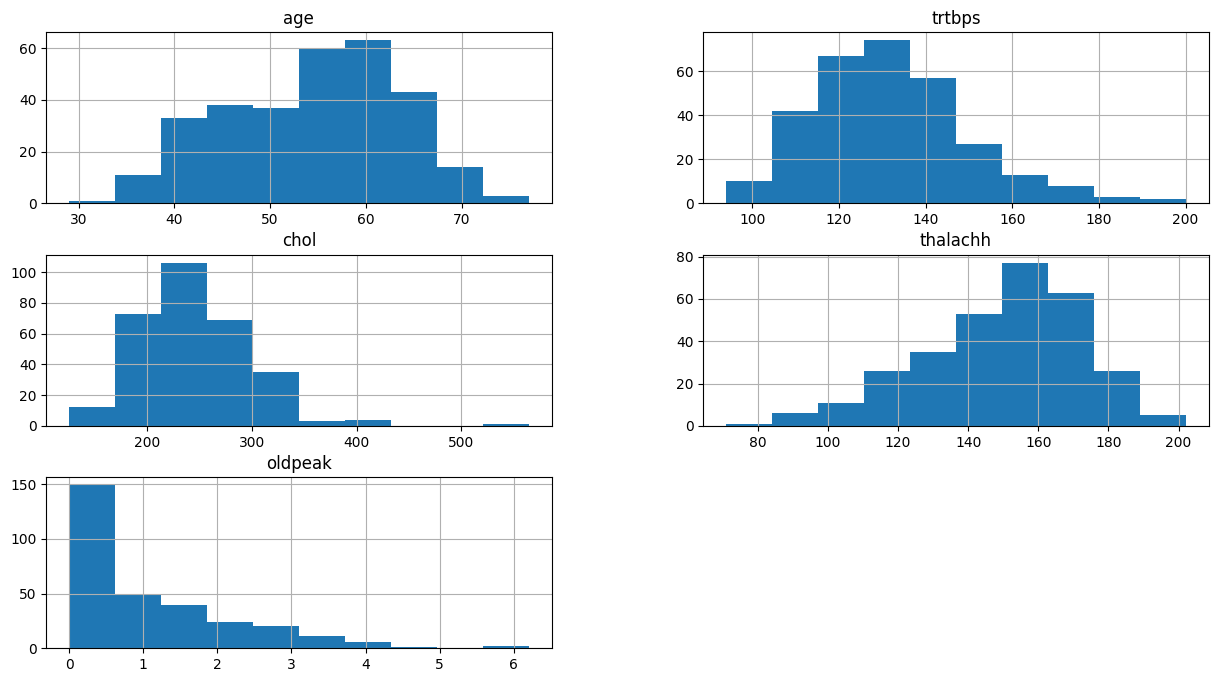

In [11]:
continuous_df = df[continuous_features]
continuous_df.hist(figsize=(15,8))

In [12]:
categorical_features = df.columns.difference(continuous_features)
df_categorical = df[categorical_features]

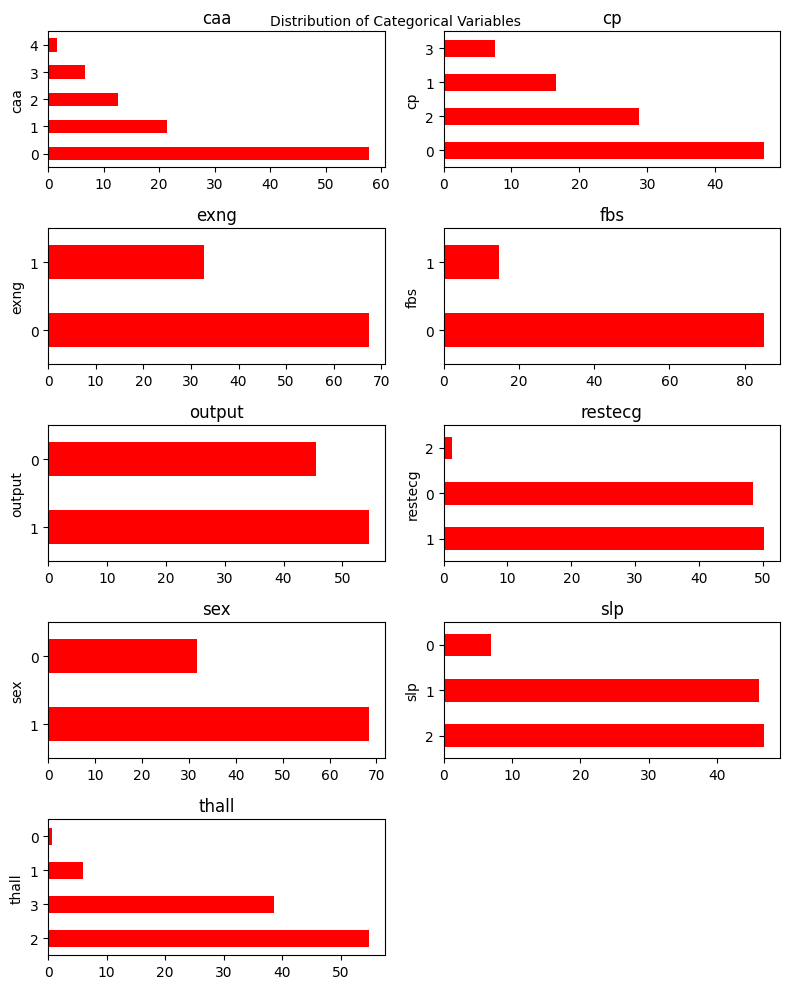

In [13]:
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(8, 10))  


for i, col in enumerate(categorical_features):  
      
    value_counts = df[col].value_counts(normalize=True).mul(100)  
    
    
    value_counts.plot(kind='barh', ax=ax[i // 2, i % 2], color='red')  

    
    ax[i // 2, i % 2].set_title(col)  


ax[4, 1].axis('off')  


plt.tight_layout()  
plt.suptitle('Distribution of Categorical Variables', fontsize=10)  
plt.show()  

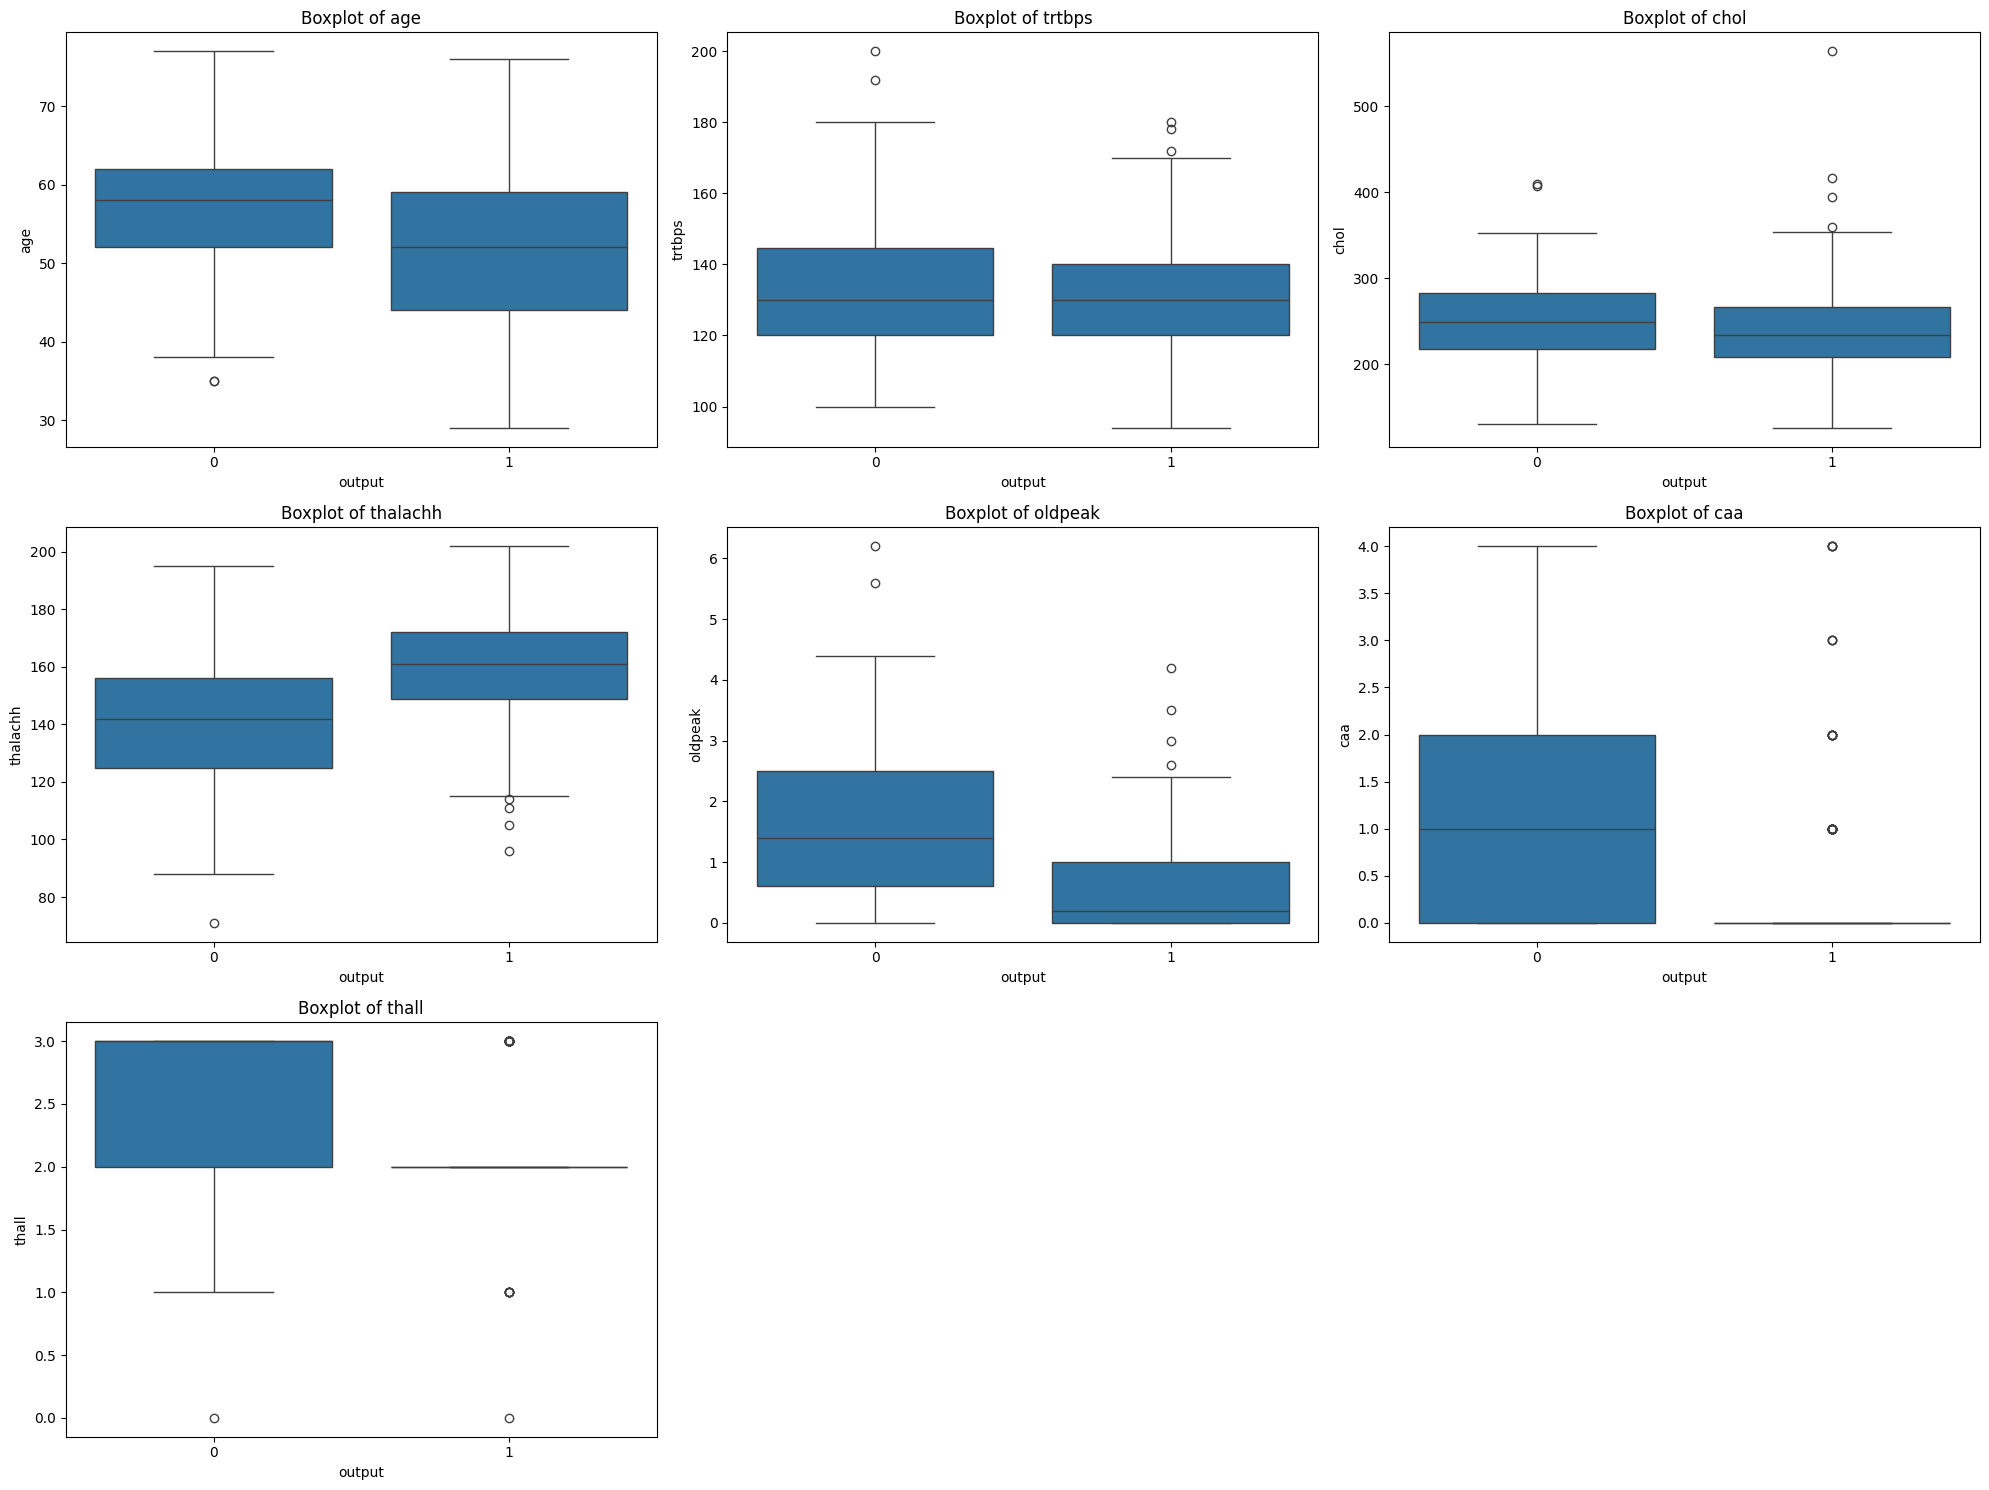

In [14]:

plt.figure(figsize=(20, 15))
df_boxplot = df.drop(['sex','cp', 'restecg', 'exng', 'slp', 'fbs'], axis=1) #dropping descrete columns for boxplot
for i, column in enumerate(df_boxplot.columns[:-1]):  
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='output', y=column, data=df_boxplot)
    plt.title('Boxplot of {}'.format(column))
    plt.tight_layout()

plt.show()

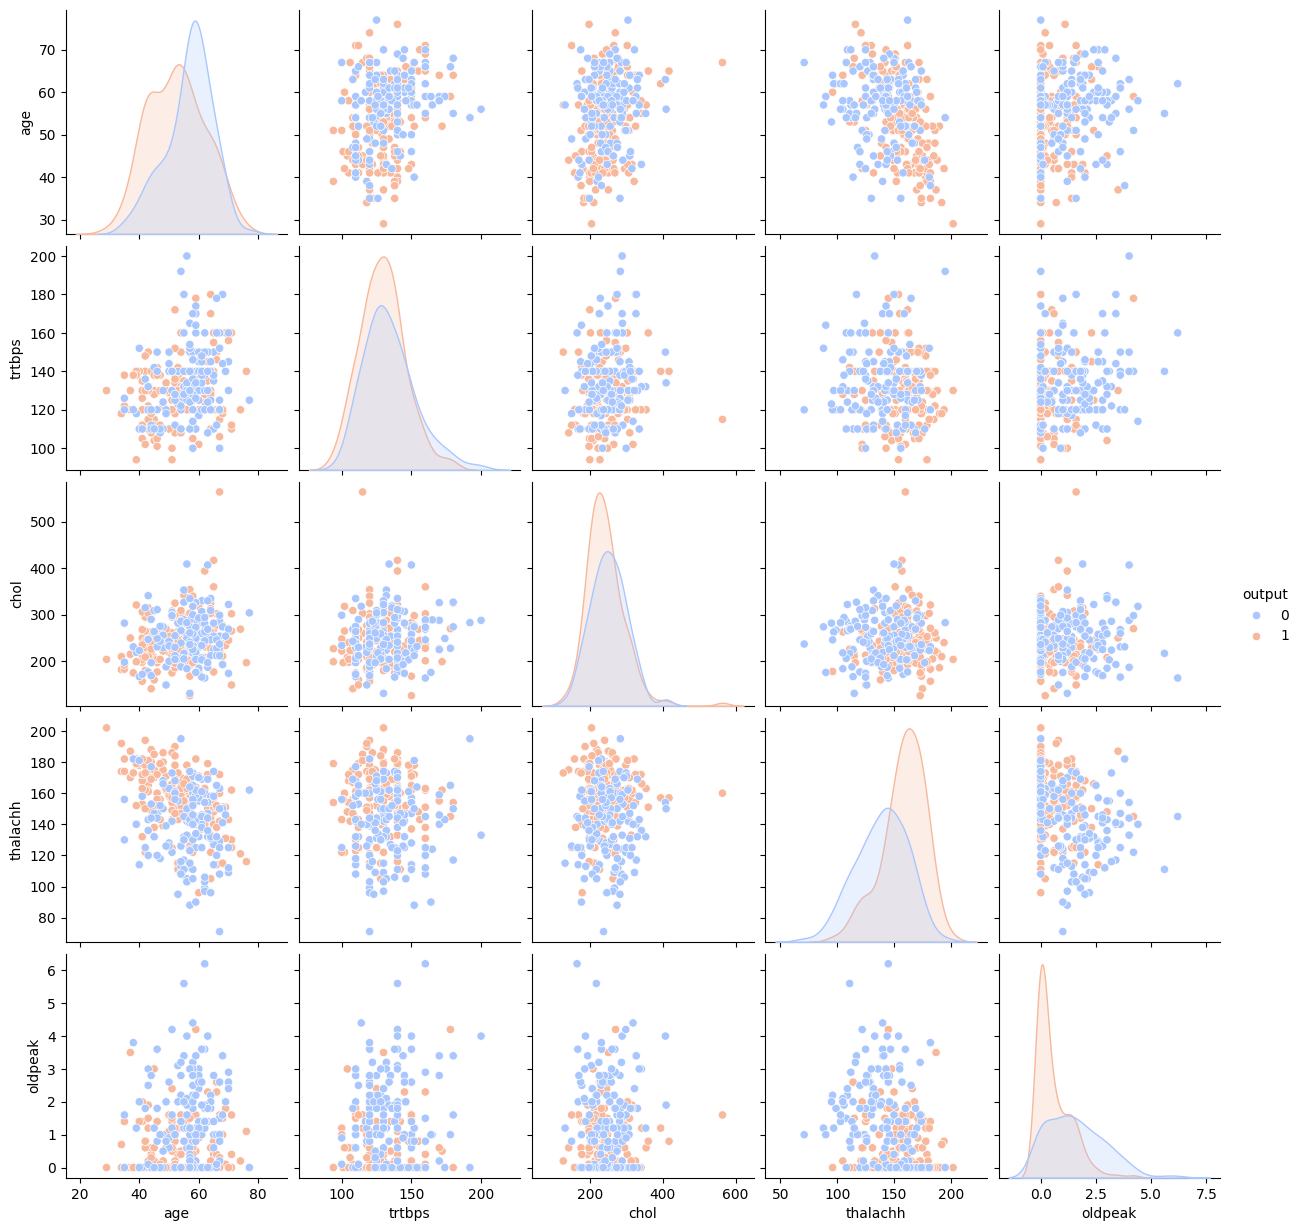

In [15]:
sns.pairplot(df, vars=continuous_features, hue="output", palette="coolwarm", diag_kind="kde")

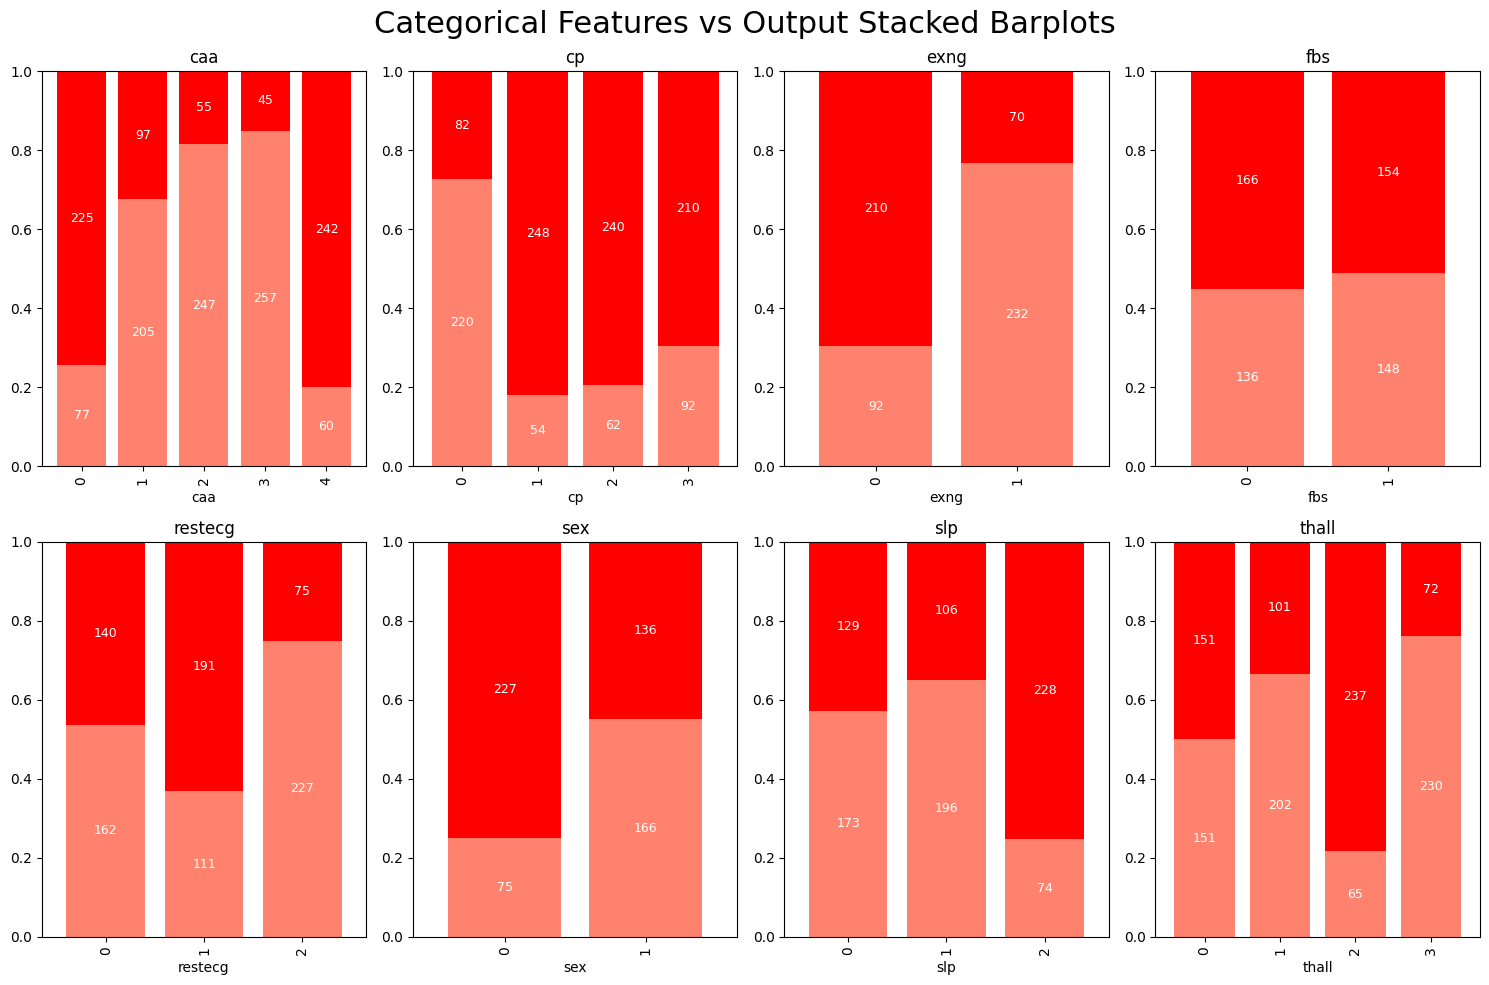

In [16]:
from matplotlib.colors import ListedColormap  

# Filter out 'output' from categorical features  
categorical_features = [feature for feature in categorical_features if feature != 'output']  
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(15, 10))  

# Define color map  
cmp = ListedColormap(['#ff826e', 'red'])  

for i, col in enumerate(categorical_features):  
    # Create normalized cross-tabulation  
    cross_tab_prop = pd.crosstab(index=df[col], columns=df['output'], normalize='index')  

    # Plot stacked bar charts  
    x, y = i // 4, i % 4  
    cross_tab_prop.plot(kind='bar', ax=ax[x, y], stacked=True, width=0.8, colormap=cmp, legend=False)  

    # Add value annotations to bars  
    for idx in range(len(cross_tab_prop)):  
        for j in range(len(cross_tab_prop.columns)):  
            ax[x, y].text(idx, cross_tab_prop.iloc[idx, :].cumsum()[j] - cross_tab_prop.iloc[idx, j] / 2,  
                           f'{int(cross_tab_prop.iloc[idx, j] * len(df) / cross_tab_prop.sum(axis=1)[idx]):d}',   
                           ha='center', va='center', color='white', fontsize=9)  

    # Set titles and labels  
    ax[x, y].set_title(col)  
    ax[x, y].set_ylim([0, 1])  
    
plt.suptitle('Categorical Features vs Output Stacked Barplots', fontsize=22)  
plt.tight_layout()  
plt.show()  

In [17]:
Q1 = df[continuous_features].quantile(0.25)
Q3 = df[continuous_features].quantile(0.75)
IQR = Q3 - Q1
outliers_count_specified = ((df[continuous_features] < (Q1 - 1.5 * IQR)) | (df[continuous_features] > (Q3 + 1.5 * IQR))).sum()

outliers_count_specified

age         0
trtbps      9
chol        5
thalachh    1
oldpeak     5
dtype: int64

One-Hot Encoding:


sex: This is a binary variable with two categories (male and female), so it doesn't need one-hot encoding.

cp: Chest pain type can be considered as nominal because there's no clear ordinal relationship among the different types of chest pain (like Typical angina, Atypical angina, etc.). It should be one-hot encoded.

fbs: This is a binary variable (true or false), so it doesn't need one-hot encoding.

restecg: This variable represents the resting electrocardiographic results. The results, such as "Normal", "Having ST-T wave abnormality", and "Showing probable or definite left ventricular hypertrophy", don't seem to have an ordinal relationship. Therefore, it should be one-hot encoded.

exang: This is a binary variable (yes or no), so it doesn't need one-hot encoding.

slope: This represents the slope of the peak exercise ST segment. Given the descriptions (Upsloping, Flat, Downsloping), it seems to have an ordinal nature, suggesting a particular order. Therefore, it doesn't need to be one-hot encoded.

ca: This represents the number of major vessels colored by fluoroscopy. As it indicates a count, it has an inherent ordinal relationship. Therefore, it doesn't need to be one-hot encoded.

thal: This variable represents the result of a thalium stress test. The different states, like "Normal", "Fixed defect", and "Reversible defect", suggest a nominal nature. Thus, it should be one-hot encoded.

Summary:

Need One-Hot Encoding: cp, restecg, thal

Don't Need One-Hot Encoding: sex, fbs, exang, slope, ca

In [18]:
df_encoded = pd.get_dummies(df, columns=['cp', 'restecg', 'thall'], drop_first=True)  


bool_columns = df_encoded.select_dtypes(include=[bool]).columns  
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)  

features_to_convert = ['sex', 'fbs', 'exng', 'slp', 'caa', 'output']  
for feature in features_to_convert:  
    if feature in df_encoded.columns:  
        df_encoded[feature] = df_encoded[feature].astype(int)  


df_encoded.dtypes

age            int64
sex            int64
trtbps         int64
chol           int64
fbs            int64
thalachh       int64
exng           int64
oldpeak      float64
slp            int64
caa            int64
output         int64
cp_1           int64
cp_2           int64
cp_3           int64
restecg_1      int64
restecg_2      int64
thall_1        int64
thall_2        int64
thall_3        int64
dtype: object

In [19]:
df_encoded.head()

,age,sex,trtbps,chol,fbs,thalachh,exng,oldpeak,slp,caa,output,cp_1,cp_2,cp_3,restecg_1,restecg_2,thall_1,thall_2,thall_3
0,63,1,145,233,1,150,0,2.3,0,0,1,0,0,1,0,0,1,0,0
1,37,1,130,250,0,187,0,3.5,0,0,1,0,1,0,1,0,0,1,0
2,41,0,130,204,0,172,0,1.4,2,0,1,1,0,0,0,0,0,1,0
3,56,1,120,236,0,178,0,0.8,2,0,1,1,0,0,1,0,0,1,0
4,57,0,120,354,0,163,1,0.6,2,0,1,0,0,0,1,0,0,1,0


<Axes: >

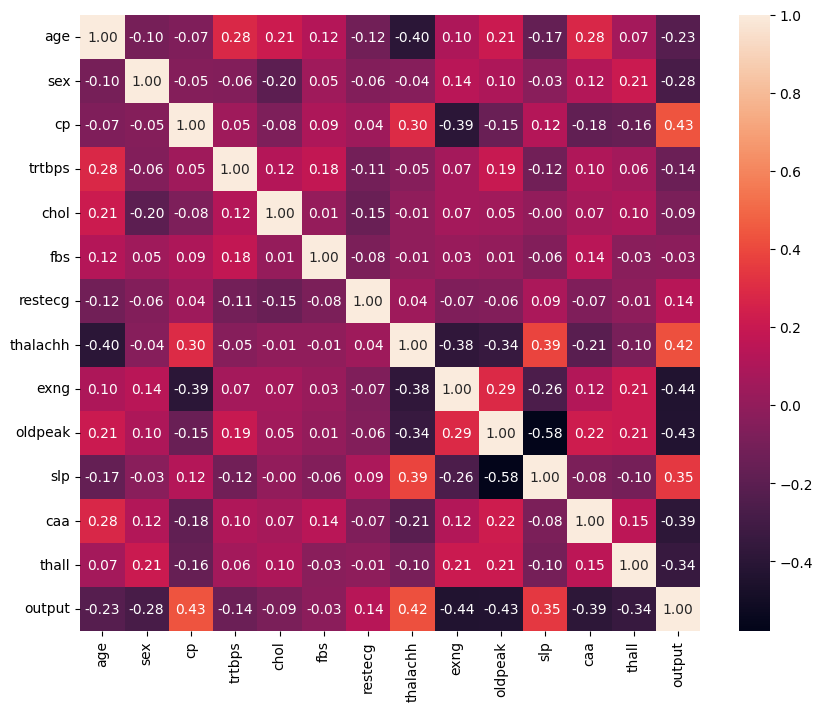

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f')

In [21]:
from sklearn.model_selection import train_test_split  

X = df_encoded.drop('output', axis=1) 
y = df_encoded['output']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier() 
clf.fit(X_train, y_train) 

KNeighborsClassifier()

In [23]:
from sklearn.metrics import accuracy_score
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.6885245901639344


In [24]:
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler 

X1 = df.drop('output', axis=1) 
y1 = df['output']
scaler = StandardScaler()  
X1_scaled = scaler.fit_transform(X)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_scaled, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier() 
clf.fit(X1_train, y1_train) 

KNeighborsClassifier()

In [26]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score, precision_score, f1_score  
y1_pred = clf.predict(X1_test)
accuracy = accuracy_score(y1_test, y1_pred) 
recall = recall_score(y1_test, y1_pred)  
precision = precision_score(y1_test, y1_pred)  
f_score = f1_score(y1_test, y1_pred)  


print(f"Recall: {recall:.4f}")  
print(f"Precision: {precision:.4f}")  
print(f"F-Score: {f_score:.4f}")  
print(f"accuracy: {accuracy:.4f}")

Recall: 0.8125
Precision: 0.8966
F-Score: 0.8525
accuracy: 0.8525


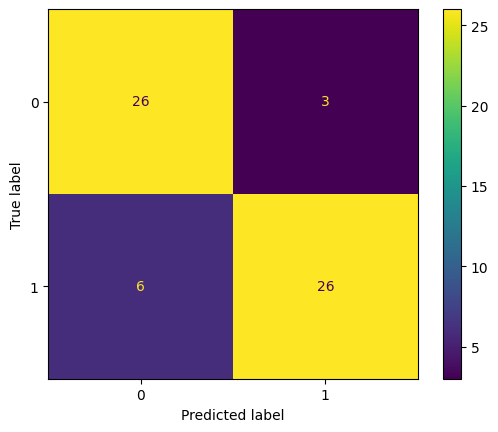

In [27]:
from sklearn.metrics import confusion_matrix 
from sklearn import metrics 
 
confusion_matrix = metrics.confusion_matrix(y1_test, y1_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])

cm_display.plot()
plt.show()

In [28]:
from sklearn.tree import DecisionTreeClassifier  
clf = DecisionTreeClassifier()  
clf.fit(X1_train, y1_train)

DecisionTreeClassifier()

In [29]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score, precision_score, f1_score  
y1_pred = clf.predict(X1_test)
accuracy = accuracy_score(y1_test, y1_pred) 
recall = recall_score(y1_test, y1_pred)  
precision = precision_score(y1_test, y1_pred)  
f_score = f1_score(y1_test, y1_pred)  


print(f"Recall: {recall:.4f}")  
print(f"Precision: {precision:.4f}")  
print(f"F-Score: {f_score:.4f}")  
print(f"accuracy: {accuracy:.4f}")

Recall: 0.7188
Precision: 0.7667
F-Score: 0.7419
accuracy: 0.7377


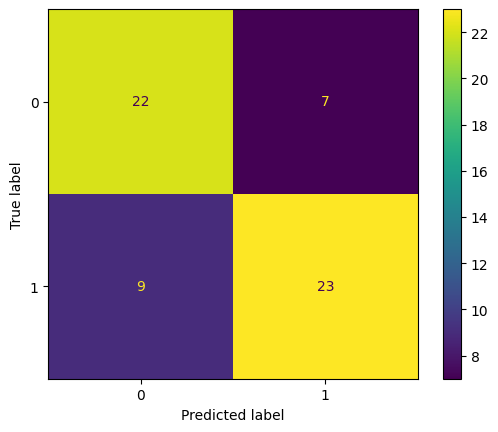

In [30]:
from sklearn.metrics import confusion_matrix 
from sklearn import metrics 
 
confusion_matrix = metrics.confusion_matrix(y1_test, y1_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])

cm_display.plot()
plt.show()

In [31]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train, y_train)

d:\university\Machine Learning\data\Reyhane-Bonyady\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [32]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X1_train, y1_train)

LogisticRegression()

In [33]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score, precision_score, f1_score  
y1_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) 
recall = recall_score(y_test, y_pred)  
precision = precision_score(y_test, y_pred)  
f_score = f1_score(y_test, y_pred)  


print(f"Recall: {recall:.4f}")  
print(f"Precision: {precision:.4f}")  
print(f"F-Score: {f_score:.4f}")  
print(f"accuracy: {accuracy:.4f}")

Recall: 0.7500
Precision: 0.6857
F-Score: 0.7164
accuracy: 0.6885


d:\university\Machine Learning\data\Reyhane-Bonyady\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [34]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score, precision_score, f1_score  
y1_pred = clf.predict(X1_test)
accuracy = accuracy_score(y1_test, y1_pred) 
recall = recall_score(y1_test, y1_pred)  
precision = precision_score(y1_test, y1_pred)  
f_score = f1_score(y1_test, y1_pred)  


print(f"Recall: {recall:.4f}")  
print(f"Precision: {precision:.4f}")  
print(f"F-Score: {f_score:.4f}")  
print(f"accuracy: {accuracy:.4f}")

Recall: 0.8750
Precision: 0.9333
F-Score: 0.9032
accuracy: 0.9016


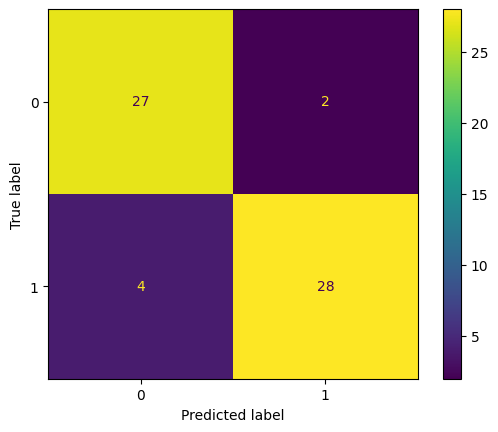

In [35]:
from sklearn.metrics import confusion_matrix 
from sklearn import metrics 
 
confusion_matrix = metrics.confusion_matrix(y1_test, y1_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])

cm_display.plot()
plt.show()

In [36]:
from sklearn.svm import SVC  
svm_linear = SVC(kernel='linear', random_state=0)  
svm_linear.fit(X1_train, y1_train)  


SVC(kernel='linear', random_state=0)

In [37]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score, precision_score, f1_score  
y1_pred = clf.predict(X1_test)
accuracy = accuracy_score(y1_test, y1_pred) 
recall = recall_score(y1_test, y1_pred)  
precision = precision_score(y1_test, y1_pred)  
f_score = f1_score(y1_test, y1_pred)  


print(f"Recall: {recall:.4f}")  
print(f"Precision: {precision:.4f}")  
print(f"F-Score: {f_score:.4f}")  
print(f"accuracy: {accuracy:.4f}")

Recall: 0.8750
Precision: 0.9333
F-Score: 0.9032
accuracy: 0.9016


In [38]:
from sklearn.svm import SVC  
svm_linear = SVC(kernel='rbf', random_state=0)  
svm_linear.fit(X1_train, y1_train)  


SVC(random_state=0)

In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score, precision_score, f1_score  
y1_pred = clf.predict(X1_test)
accuracy = accuracy_score(y1_test, y1_pred) 
recall = recall_score(y1_test, y1_pred)  
precision = precision_score(y1_test, y1_pred)  
f_score = f1_score(y1_test, y1_pred)  


print(f"Recall: {recall:.4f}")  
print(f"Precision: {precision:.4f}")  
print(f"F-Score: {f_score:.4f}")  
print(f"accuracy: {accuracy:.4f}")

Recall: 0.8750
Precision: 0.9333
F-Score: 0.9032
accuracy: 0.9016


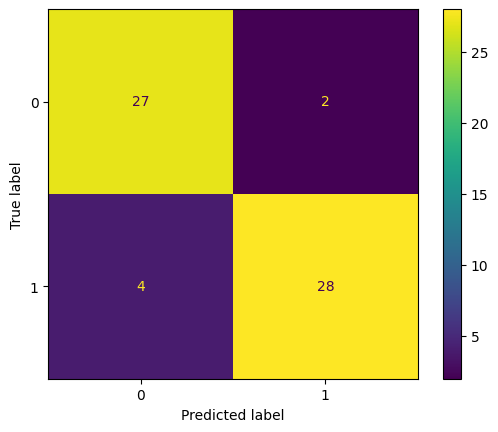

In [40]:
from sklearn.metrics import confusion_matrix 
from sklearn import metrics 
 
confusion_matrix = metrics.confusion_matrix(y1_test, y1_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])

cm_display.plot()
plt.show()

| Model               | Accuracy | Recall | Precision | F-Score |  
|---------------------|----------|--------|-----------|---------|  
| KNN                 | 0.8525     | 0.8125   | 0.8966      | 0.8525    |  
| Decision Tree       | 0.7377     | 0.718   | 0.7667      | 0.7419    |  
| Logistic Regression  | 0.9016     | 0.875   | 0.9333      | 0.9032    |  
| SVM                 | 0.9016     | 0.875   | 0.9333      | 0.9032    |